In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "7"

import matplotlib.pyplot as plt
import torch
from diffusers import (
    StableDiffusionXLPipeline,
    StableDiffusion3Pipeline,
    FluxPipeline,
)

torch.set_grad_enabled(False)
device = torch.device("cuda")

/local2/kunkim/textboost-dev/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# SDXL

In [2]:
pipeline = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.bfloat16,
).to(device)

Loading pipeline components...: 100%|██████████| 7/7 [00:06<00:00,  1.14it/s]


100%|██████████| 50/50 [00:08<00:00,  5.62it/s]


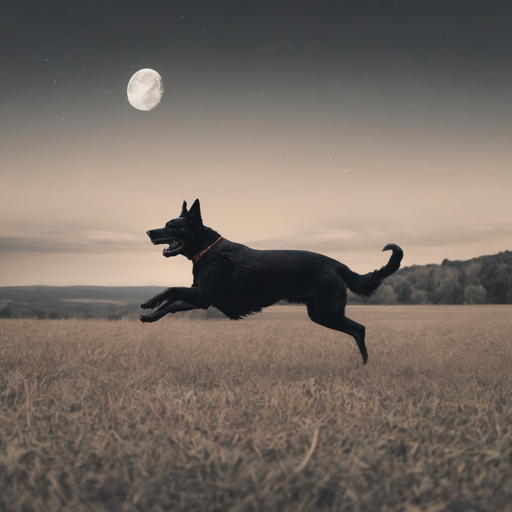

In [5]:
# Text Encoder 1: Small CLIP
# Text Encoder 2: Big CLIP
images = pipeline(
    prompt="a man on the moon",
    prompt_2="a black dog running on the field",
).images

images[0].resize((512, 512))

# SD 3.5

In [2]:
pipeline = StableDiffusion3Pipeline.from_pretrained(
    "stabilityai/stable-diffusion-3.5-medium",
    torch_dtype=torch.bfloat16,
).to(device)

Loading pipeline components...: 100%|██████████| 9/9 [00:03<00:00,  2.48it/s]


100%|██████████| 28/28 [00:09<00:00,  3.08it/s]


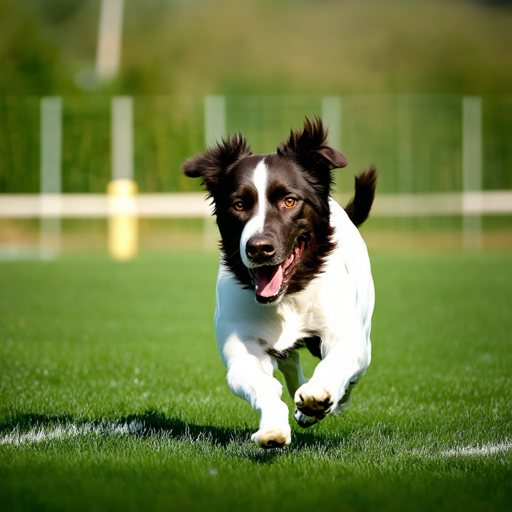

In [20]:
images = pipeline(
    prompt="a brown dog running on the field",
    prompt_2="a black dog running on the field",
    prompt_3="a white dog running on the field",
).images

images[0].resize((512, 512))

# FLUX.1

In [3]:
pipeline = FluxPipeline.from_pretrained(
    "black-forest-labs/FLUX.1-dev",
    torch_dtype=torch.bfloat16,
).to(device)

Fetching 23 files:   0%|          | 0/23 [00:00<?, ?it/s]Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Fetching 23 files:   9%|▊         | 2/23 [00:00<00:04,  4.94it/s]Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install

In [4]:
print(pipeline.text_encoder)
print(pipeline.text_encoder_2)

CLIPTextModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 768)
      (position_embedding): Embedding(77, 768)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPSdpaAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), ep

100%|██████████| 28/28 [00:26<00:00,  1.05it/s]


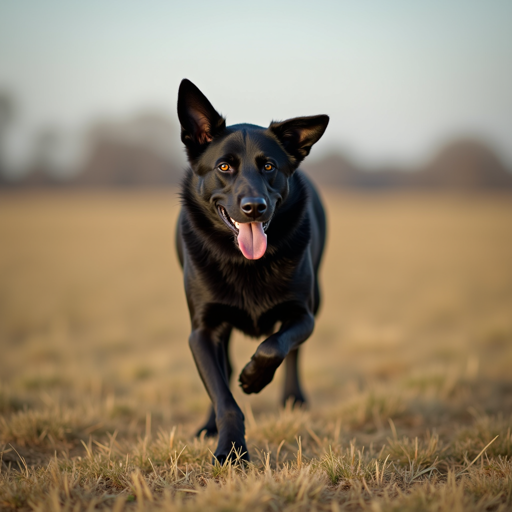

In [5]:
images = pipeline(
    prompt="a man on the moon",
    prompt_2="a black dog running on the field",
).images

images[0].resize((512, 512))